# Clustering — La Paz Traffic

- **DBSCAN espacial**: agrupa segmentos por proximidad geográfica
- **K-Means temporal**: agrupa por perfil de congestión horaria
- **DataFrame maestro**: cruza ambos resultados

## 1. Imports y carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score

DATA_RAW       = Path('../data/raw')
DATA_PROCESSED = Path('../data/processed')
TIPOS_DIA      = ['lunes', 'viernes', 'sabado']

segments  = pd.read_csv(DATA_RAW / 'sample_segments.csv')
feat_raw  = pd.read_csv(DATA_PROCESSED / 'feature_matrix.csv', index_col='segment_id')
pca_embed = pd.read_csv(DATA_PROCESSED / 'pca_embedding.csv', index_col='segment_id')
umap_df   = pd.read_csv(DATA_PROCESSED / 'umap_embedding.csv')

jam_mean = feat_raw.mean(axis=1).rename('jam_mean')
print(f'Segmentos: {len(segments)} | PCA: {pca_embed.shape} | jam_mean: [{jam_mean.min():.3f}, {jam_mean.max():.3f}]')

Segmentos: 250 | PCA: (250, 13) | jam_mean: [0.000, 2.101]


## 2. DBSCAN espacial

In [2]:
coords_rad = np.radians(segments[['lat', 'lon']].values)
EARTH_KM = 6371.0

resultados = []
for eps_km in [0.5, 1.0, 2.0, 3.0]:
    eps_rad = eps_km / EARTH_KM
    for min_s in [3, 5, 10]:
        labels = DBSCAN(eps=eps_rad, min_samples=min_s, metric='haversine').fit_predict(coords_rad)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        mask = labels != -1
        sil = -1.0
        if n_clusters >= 2 and mask.sum() > n_clusters:
            try: sil = silhouette_score(coords_rad[mask], labels[mask])
            except: pass
        resultados.append({'eps_km': eps_km, 'min_samples': min_s,
                           'n_clusters': n_clusters, 'pct_noise': n_noise/len(labels)*100, 'silhouette': sil})

res_df = pd.DataFrame(resultados)
print(res_df.to_string(index=False))

 eps_km  min_samples  n_clusters  pct_noise  silhouette
    0.5            3          22       33.6    0.471381
    0.5            5          11       68.0    0.681148
    0.5           10           0      100.0   -1.000000
    1.0            3           5        8.4    0.156695
    1.0            5           4       12.4    0.182196
    1.0           10           5       42.4    0.348109
    2.0            3           1        3.2   -1.000000
    2.0            5           1        4.0   -1.000000
    2.0           10           1        4.8   -1.000000
    3.0            3           2        2.0    0.581518
    3.0            5           1        3.2   -1.000000
    3.0           10           1        3.2   -1.000000


In [3]:
candidatos = res_df[(res_df['silhouette'] > 0) & (res_df['pct_noise'] < 30)]
if candidatos.empty:
    candidatos = res_df[res_df['silhouette'] > 0]
if candidatos.empty:
    mejor = res_df.loc[res_df['pct_noise'].idxmin()]
else:
    mejor = candidatos.loc[candidatos['silhouette'].idxmax()]

print(f'Mejores parámetros: eps={mejor["eps_km"]} km | min_samples={int(mejor["min_samples"])}')
print(f'n_clusters={int(mejor["n_clusters"])} | outliers={mejor["pct_noise"]:.1f}% | silhouette={mejor["silhouette"]:.3f}')

labels_spatial = DBSCAN(eps=mejor['eps_km']/EARTH_KM, min_samples=int(mejor['min_samples']),
                         metric='haversine').fit_predict(coords_rad)

clusters_spatial = segments[['segment_id','lat','lon','highway','length']].copy()
clusters_spatial['cluster_espacial'] = labels_spatial
clusters_spatial['jam_mean'] = clusters_spatial['segment_id'].map(jam_mean)
clusters_spatial.to_csv(DATA_PROCESSED / 'clusters_spatial.csv', index=False)
print('\nDistribución clusters espaciales:')
print(clusters_spatial['cluster_espacial'].value_counts().sort_index())

Mejores parámetros: eps=3.0 km | min_samples=3
n_clusters=2 | outliers=2.0% | silhouette=0.582

Distribución clusters espaciales:
cluster_espacial
-1      5
 0    242
 1      3
Name: count, dtype: int64


## 3. K-Means temporal

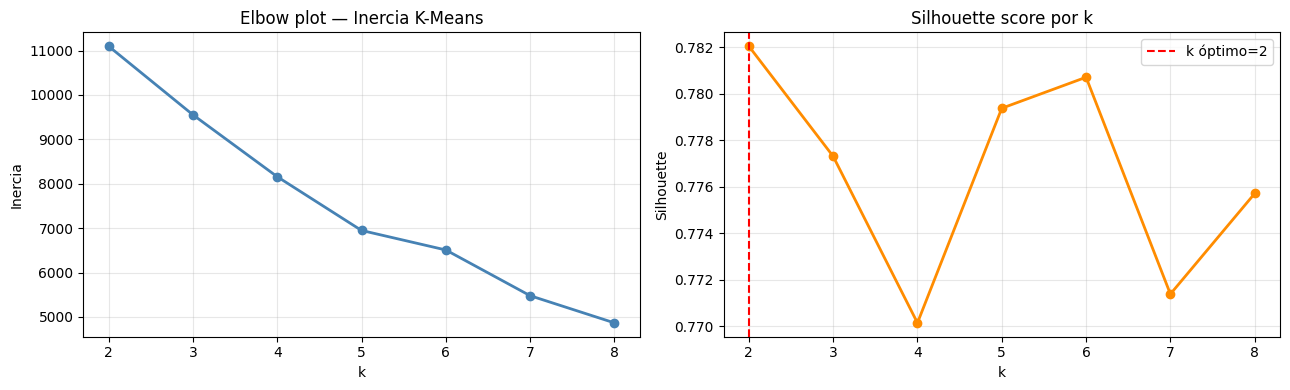

k óptimo: 2 (silhouette=0.782)


In [4]:
X_km = pca_embed.values
inercias, silhouettes = [], []
K_RANGE = range(2, 9)

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    lbl = km.fit_predict(X_km)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_km, lbl))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(K_RANGE), inercias, 'o-', color='steelblue', linewidth=2)
axes[0].set_title('Elbow plot — Inercia K-Means')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia'); axes[0].grid(True, alpha=0.3)

k_optimo = list(K_RANGE)[np.argmax(silhouettes)]
axes[1].plot(list(K_RANGE), silhouettes, 'o-', color='darkorange', linewidth=2)
axes[1].axvline(k_optimo, color='red', linestyle='--', label=f'k óptimo={k_optimo}')
axes[1].set_title('Silhouette score por k')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'kmeans_elbow.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'k óptimo: {k_optimo} (silhouette={max(silhouettes):.3f})')

=== Perfil por cluster temporal ===
Cluster 0: 28 seg | jam_prom=0.756 | hora_pico=19h | vía=residential
Cluster 1: 222 seg | jam_prom=0.034 | hora_pico=19h | vía=residential


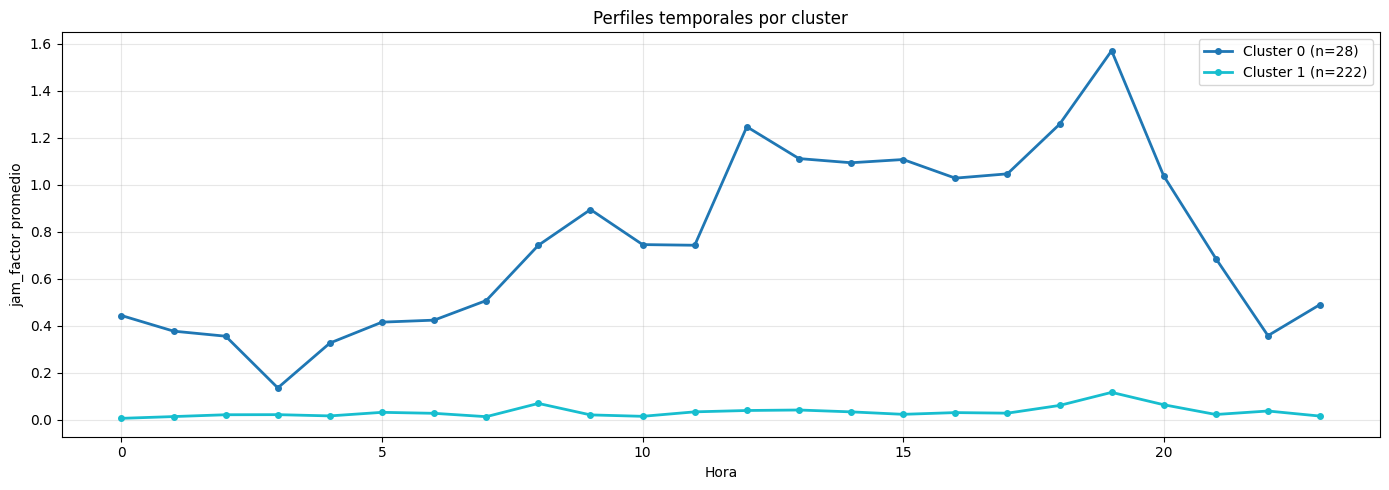

Guardado: data/processed/cluster_profiles.png


In [5]:
labels_temporal = KMeans(n_clusters=k_optimo, n_init=10, random_state=42).fit_predict(X_km)

clusters_temporal = pd.DataFrame({'segment_id': pca_embed.index, 'cluster_temporal': labels_temporal})
clusters_temporal.to_csv(DATA_PROCESSED / 'clusters_temporal.csv', index=False)

feat_cc = feat_raw.copy()
feat_cc['cluster_temporal'] = labels_temporal

print('=== Perfil por cluster temporal ===')
fig, ax = plt.subplots(figsize=(14, 5))
colores_c = plt.cm.tab10(np.linspace(0, 1, k_optimo))

for c in sorted(clusters_temporal['cluster_temporal'].unique()):
    mask = feat_cc['cluster_temporal'] == c
    n_seg = mask.sum()
    jam_prom = feat_raw[mask].values.mean()
    perfil_h = [feat_raw.loc[mask, [f'jam_{d}_{h:02d}' for d in TIPOS_DIA]].values.mean() for h in range(24)]
    hora_pico = np.argmax(perfil_h)
    seg_ids = clusters_temporal[clusters_temporal['cluster_temporal']==c]['segment_id']
    hw_dom = segments[segments['segment_id'].isin(seg_ids)]['highway'].mode()
    hw_dom = hw_dom.iloc[0] if not hw_dom.empty else 'N/A'
    print(f'Cluster {c}: {n_seg} seg | jam_prom={jam_prom:.3f} | hora_pico={hora_pico:02d}h | vía={hw_dom}')
    ax.plot(range(24), perfil_h, 'o-', markersize=4, label=f'Cluster {c} (n={n_seg})',
            color=colores_c[c], linewidth=2)

ax.set_title('Perfiles temporales por cluster')
ax.set_xlabel('Hora'); ax.set_ylabel('jam_factor promedio'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'cluster_profiles.png', dpi=120, bbox_inches='tight')
plt.show()
print('Guardado: data/processed/cluster_profiles.png')

## 4. DataFrame maestro

In [6]:
maestro = segments[['segment_id','lat','lon','highway','length']].copy()
maestro['jam_mean'] = maestro['segment_id'].map(jam_mean)
maestro = maestro.merge(clusters_spatial[['segment_id','cluster_espacial']], on='segment_id', how='left')
maestro = maestro.merge(clusters_temporal[['segment_id','cluster_temporal']], on='segment_id', how='left')
maestro = maestro.merge(umap_df[['segment_id','umap_x','umap_y']], on='segment_id', how='left')
maestro.to_csv(DATA_PROCESSED / 'segments_clustered.csv', index=False)

print(f'DataFrame maestro: {maestro.shape}')
print(f'NaN clusters: {maestro[["cluster_espacial","cluster_temporal"]].isna().sum().to_dict()}')
maestro.head(5)

DataFrame maestro: (250, 10)
NaN clusters: {'cluster_espacial': 0, 'cluster_temporal': 0}


,segment_id,lat,lon,highway,length,jam_mean,cluster_espacial,cluster_temporal,umap_x,umap_y
0,0,-16.517571,-68.051592,residential,93.356595,0.0,0,1,20.498533,40.768100
1,1,-16.533906,-68.129547,residential,260.907870,0.0,0,1,19.398710,40.097652
2,2,-16.518653,-68.056460,residential,49.950192,0.0,0,1,20.272020,39.901054
3,3,-16.490366,-68.104952,residential,43.156481,0.0,0,1,19.404005,39.960320
4,4,-16.548545,-68.096270,residential,103.887536,0.0,0,1,19.846470,40.448677


## 5. Resumen

Próximo paso: **FASE 8 — Visualización estática** (mapas Folium + gráficos de perfil).